<a href="https://colab.research.google.com/github/Shreevidhya08/Generative-AI/blob/main/GANs/GAN_pixs_to_pixs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"shreevidhyabbtech23","key":"8709bfa75ab7e2b19ec3f7da0cb32d56"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d vikramtiwari/pix2pix-dataset
!unzip pix2pix-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: edges2shoes/edges2shoes/train/8200_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8201_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8202_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8203_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8204_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8205_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8206_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8207_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8208_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8209_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/820_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8210_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8211_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8212_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8213_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8214_AB.jpg  
  inflating: edges2shoes/edges2shoes/t

In [ ]:
train_path = "facades/facades/train"

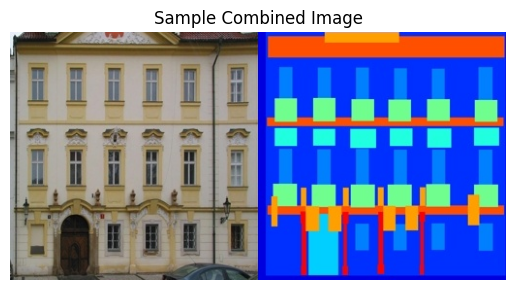

In [ ]:
from PIL import Image
import os
import matplotlib.pyplot as plt

files = os.listdir(train_path)
img = Image.open(os.path.join(train_path, files[0]))

plt.imshow(img)
plt.title("Sample Combined Image")
plt.axis("off")
plt.show()

In [ ]:
import os
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms

class FacadesDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.files = os.listdir(root_dir)

        self.transform = transforms.Compose([
            transforms.Resize((256,256)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.root_dir, self.files[idx]))
        w, h = img.size

         # LEFT half = real photo
        photo = img.crop((0, 0, w//2, h))

         # RIGHT half = label map
        label = img.crop((w//2, 0, w, h))
        return self.transform(label), self.transform(photo)

In [ ]:
from torch.utils.data import DataLoader

train_dataset = FacadesDataset(train_path)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)

In [ ]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Basic UNetGenerator (example - actual implementation might be more complex)
class UNetGenerator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()
        # Simplified for demonstration. A full U-Net would have encoder-decoder blocks.
        self.main = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, out_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

# Basic Discriminator (example - actual implementation might be more complex)
class Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(in_channels * 2, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=1),
            # No sigmoid here, BCEWithLogitsLoss expects raw logits
        )

    def forward(self, input, target):
        # Concatenate input and target images channel-wise
        x = torch.cat([input, target], 1)
        return self.main(x)

G = UNetGenerator().to(device)
D = Discriminator().to(device)

opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5,0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5,0.999))

criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1 = nn.L1Loss()

lambda_L1 = 100

for epoch in range(20):   # start with 10
    for real_A, real_B in train_loader:
        real_A, real_B = real_A.to(device), real_B.to(device)

        valid = torch.ones_like(D(real_A, real_B))
        fake = torch.zeros_like(valid)

        # ----- Train Generator -----
        opt_G.zero_grad()
        fake_B = G(real_A)
        loss_G = criterion_GAN(D(real_A,fake_B), valid) + lambda_L1*criterion_L1(fake_B,real_B)
        loss_G.backward()
        opt_G.step()

        # ----- Train Discriminator -----
        opt_D.zero_grad()
        loss_real = criterion_GAN(D(real_A,real_B), valid)
        loss_fake = criterion_GAN(D(real_A,fake_B.detach()), fake)
        loss_D = (loss_real + loss_fake)/2
        loss_D.backward()
        opt_D.step()

    print(f"Epoch {epoch+1} | G Loss: {loss_G.item():.4f} | D Loss: {loss_D.item():.4f}")

Epoch 1 | G Loss: 35.1493 | D Loss: 0.0202


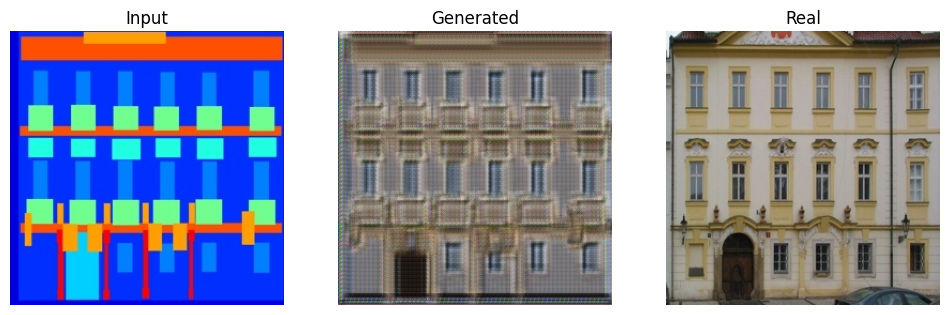

In [ ]:
import matplotlib.pyplot as plt

real_A, real_B = next(iter(train_loader))
real_A = real_A.to(device)

with torch.no_grad():
    fake_B = G(real_A)

# Denormalize
def denorm(x):
    return x * 0.5 + 0.5

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input")
plt.imshow(denorm(real_A[0]).permute(1,2,0).cpu())
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Generated")
plt.imshow(denorm(fake_B[0]).permute(1,2,0).cpu())
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Real")
plt.imshow(denorm(real_B[0]).permute(1,2,0))
plt.axis("off")

plt.show()

In [ ]:
data_iter = iter(train_loader)
real_A, real_B = next(data_iter)